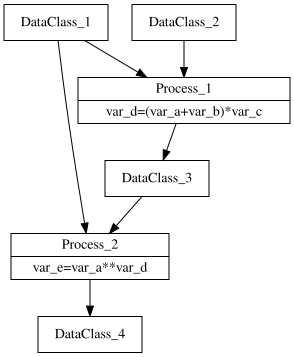

1048576.0


In [1]:
from dataclasses import dataclass
from typing import Dict, Any, Type
import graphviz
from IPython.display import display, SVG

@dataclass
class DataClass_1:
    var_a: float
    var_b: float

@dataclass
class DataClass_2:
    var_c: float

@dataclass
class DataClass_3:
    var_d: float

@dataclass
class DataClass_4:
    var_e: float

class Process:
    input_classes: Dict[str, Type]
    output_classes: Dict[str, Type]
    computation: str = ""

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        raise NotImplementedError

class Process_1(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2}
    output_classes = {'DataClass_3': DataClass_3}
    computation = "var_d=(var_a+var_b)*var_c"

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        dc1 = inputs['DataClass_1']
        dc2 = inputs['DataClass_2']
        var_d = (dc1.var_a + dc1.var_b) * dc2.var_c
        return {'DataClass_3': DataClass_3(var_d)}

class Process_2(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3}
    output_classes = {'DataClass_4': DataClass_4}
    computation = "var_e=var_a**var_d"

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        dc1 = inputs['DataClass_1']
        dc3 = inputs['DataClass_3']
        var_e = dc1.var_a ** dc3.var_d
        return {'DataClass_4': DataClass_4(var_e)}

class ProcessGraph:
    def __init__(self):
        self.data_nodes = set()
        self.process_nodes = set()
        self.edges = []
        self.class_map: Dict[str, Type] = {}

    def add_process(self, process_class: Type[Process]):
        self.process_nodes.add(process_class.__name__)
        for input_name, input_class in process_class.input_classes.items():
            self.data_nodes.add(input_name)
            self.class_map[input_name] = input_class
            self.edges.append((input_name, process_class.__name__))
        for output_name, output_class in process_class.output_classes.items():
            self.data_nodes.add(output_name)
            self.class_map[output_name] = output_class
            self.edges.append((process_class.__name__, output_name))

    def to_graphviz(self, name="SumSquare", rankdir="TD"):
        dot = graphviz.Digraph(name=name, graph_attr={'rankdir': rankdir})
        
        # Add data nodes with record shape showing fields
        for data in self.data_nodes:
            fields = list(self.class_map[data].__annotations__.keys())
            label = '{' + data + ' | ' + ' | '.join(fields) + '}'
            label = '{' + data + '}'
            dot.node(data, shape='record', label=label)
        
        # Add process nodes with record shape showing computation
        for proc in self.process_nodes:
            proc_class = globals()[proc]
            label = '{' + proc + ' | ' + proc_class.computation + '}'
            dot.node(proc, shape='record', label=label)
        
        # Add edges
        for src, dst in self.edges:
            dot.edge(src, dst)
        
        return dot

# Example usage:
g = ProcessGraph()
g.add_process(Process_1)
g.add_process(Process_2)

# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="SumSquare", rankdir="TD")
display(SVG(dot_graph.pipe(format='svg')))

# Example execution (unchanged):
inputs_1 = {
    'DataClass_1': DataClass_1(var_a=2.0, var_b=3.0),
    'DataClass_2': DataClass_2(var_c=4.0)
}
p1 = Process_1()
output_1 = p1.execute(inputs_1)
dc3 = output_1['DataClass_3']

inputs_2 = {
    'DataClass_1': inputs_1['DataClass_1'],
    'DataClass_3': dc3
}
p2 = Process_2()
output_2 = p2.execute(inputs_2)
dc4 = output_2['DataClass_4']
print(dc4.var_e)  # Outputs: 1048576.0

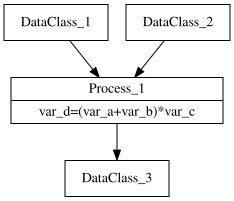

In [2]:
g = ProcessGraph()
g.add_process(Process_1)

# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="SumSquare", rankdir="TD")
display(SVG(dot_graph.pipe(format='svg')))

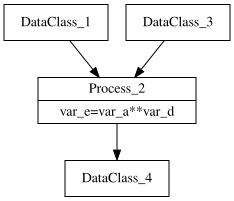

In [3]:
g = ProcessGraph()
g.add_process(Process_2)

# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="SumSquare", rankdir="TD")
display(SVG(dot_graph.pipe(format='svg')))

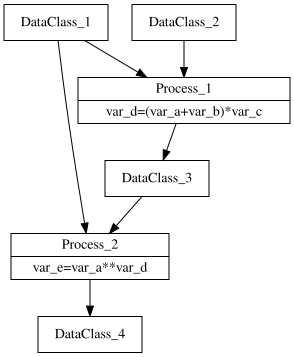

In [4]:
g = ProcessGraph()
g.add_process(Process_1)
g.add_process(Process_2)

# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="SumSquare", rankdir="TD")
display(SVG(dot_graph.pipe(format='svg')))


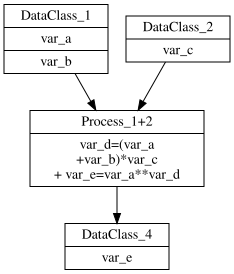

1048576.0


In [5]:
from dataclasses import dataclass, fields
from typing import Dict, Any, Type, List, Union
import graphviz
from IPython.display import display, SVG

@dataclass
class DataClass_1:
    var_a: float
    var_b: float

@dataclass
class DataClass_2:
    var_c: float

@dataclass
class DataClass_3:
    var_d: float

@dataclass
class DataClass_4:
    var_e: float

@dataclass
class DataClass_5:
    var_f: float

@dataclass
class DataClass_6:
    var_g: float

class Process:
    input_classes: Dict[str, Type]
    output_classes: Dict[str, Type]
    computation: str = ""

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        raise NotImplementedError

class Process_1(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2}
    output_classes = {'DataClass_3': DataClass_3}
    computation = "var_d=(var_a+var_b)*var_c"

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        dc1 = inputs['DataClass_1']
        dc2 = inputs['DataClass_2']
        var_d = (dc1.var_a + dc1.var_b) * dc2.var_c
        return {'DataClass_3': DataClass_3(var_d)}

class Process_2(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3}
    output_classes = {'DataClass_4': DataClass_4}
    computation = "var_e=var_a**var_d"

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        dc1 = inputs['DataClass_1']
        dc3 = inputs['DataClass_3']
        var_e = dc1.var_a ** dc3.var_d
        return {'DataClass_4': DataClass_4(var_e)}

class Process_3(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_5': DataClass_5}
    output_classes = {'DataClass_6': DataClass_6}
    computation = "var_e=var_a**var_d"

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        dc1 = inputs['DataClass_1']
        dc3 = inputs['DataClass_3']
        var_e = dc1.var_a ** dc3.var_d
        return {'DataClass_4': DataClass_4(var_e)}

class CompositeProcess(Process):
    def __init__(self, name: str, processes: List[Type[Process]]):
        self.name = name
        self.processes = [p() for p in processes]  # Instantiate the processes
        self.input_classes = {}
        self.output_classes = {}
        self.computation = ""
        self._compute_aggregated_io()

    def _compute_aggregated_io(self):
        # Collect all unique inputs and outputs
        all_inputs = set()
        all_outputs = set()
        internal_connections = set()

        for proc in self.processes:
            for inp in proc.input_classes.keys():
                all_inputs.add(inp)
            for out in proc.output_classes.keys():
                all_outputs.add(out)

        # Find internal connections: outputs that are used as inputs in subsequent processes
        for i, proc in enumerate(self.processes):
            for out in proc.output_classes.keys():
                for next_proc in self.processes[i+1:]:
                    if out in next_proc.input_classes:
                        internal_connections.add(out)

        # External inputs: all inputs minus internal ones
        external_inputs = all_inputs - internal_connections
        # External outputs: all outputs that are not fully consumed internally (assuming all outputs are final if not input elsewhere)
        external_outputs = all_outputs - all_inputs  # Outputs not used as inputs anywhere

        # Set input_classes to external inputs
        for inp in external_inputs:
            # Find the class type from one of the processes
            for proc in self.processes:
                if inp in proc.input_classes:
                    self.input_classes[inp] = proc.input_classes[inp]
                    break

        # Set output_classes to external outputs
        for out in external_outputs:
            for proc in self.processes:
                if out in proc.output_classes:
                    self.output_classes[out] = proc.output_classes[out]
                    break

        # Combine computations for display
        self.computation = " + ".join([p.computation for p in self.processes])

    def execute(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        intermediate = inputs.copy()
        for proc in self.processes:
            # Prepare inputs for this process
            proc_inputs = {k: intermediate[k] for k in proc.input_classes if k in intermediate}
            # Execute
            proc_output = proc.execute(proc_inputs)
            # Merge outputs into intermediate
            intermediate.update(proc_output)
        # Return only the external outputs
        return {k: intermediate[k] for k in self.output_classes}

class ProcessGraph:
    def __init__(self):
        self.data_nodes = set()
        self.process_nodes = set()
        self.edges = []
        self.class_map: Dict[str, Type] = {}
        self.composites: Dict[str, CompositeProcess] = {}

    def add_process(self, process: Union[Type[Process], CompositeProcess]):
        if isinstance(process, CompositeProcess):
            proc_name = process.name
            self.composites[proc_name] = process
        else:
            proc_name = process.__name__
        
        self.process_nodes.add(proc_name)
        
        if isinstance(process, CompositeProcess):
            input_classes = process.input_classes
            output_classes = process.output_classes
            computation = process.computation
        else:
            input_classes = process.input_classes
            output_classes = process.output_classes
            computation = process.computation
        
        for input_name, input_class in input_classes.items():
            self.data_nodes.add(input_name)
            self.class_map[input_name] = input_class
            self.edges.append((input_name, proc_name))
        
        for output_name, output_class in output_classes.items():
            self.data_nodes.add(output_name)
            self.class_map[output_name] = output_class
            self.edges.append((proc_name, output_name))

    def to_graphviz(self, name="SumSquare", rankdir="TD", collapsed=True):
        dot = graphviz.Digraph(name=name, graph_attr={'rankdir': rankdir})
        
        if collapsed:
            # Render composites as single nodes
            for data in self.data_nodes:
                fields = list(self.class_map[data].__annotations__.keys())
                label = '{' + data + ' | ' + ' | '.join(fields) + '}'
                dot.node(data, shape='record', label=label)
            
            for proc in self.process_nodes:
                if proc in self.composites:
                    comp = self.composites[proc]
                    label = '{' + proc + ' | ' + comp.computation.replace('+', '\\n+') + '}'
                else:
                    proc_class = globals()[proc]
                    label = '{' + proc + ' | ' + proc_class.computation + '}'
                dot.node(proc, shape='record', label=label)
            
            # Add edges (already external)
            for src, dst in self.edges:
                dot.edge(src, dst)
        
        else:
            # For non-collapsed, we'd need to render internals, but for simplicity, assuming collapsed view here
            pass  # Implement if needed for detailed view
        
        return dot

# Example usage:
composite = CompositeProcess("Process_1+2", [Process_1, Process_2])

g = ProcessGraph()
g.add_process(composite)

# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

# Example execution:
inputs = {
    'DataClass_1': DataClass_1(var_a=2.0, var_b=3.0),
    'DataClass_2': DataClass_2(var_c=4.0)
}
output = composite.execute(inputs)
dc4 = output['DataClass_4']
print(dc4.var_e)  # Outputs: 1048576.0


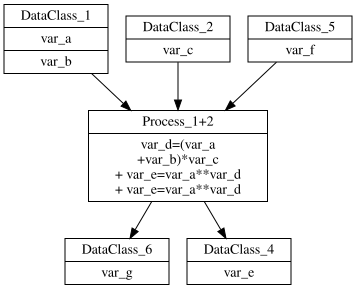

In [6]:
# Example usage:
composite = CompositeProcess("Process_1+2", [Process_1, Process_2, Process_3])

g = ProcessGraph()
g.add_process(composite)

# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))


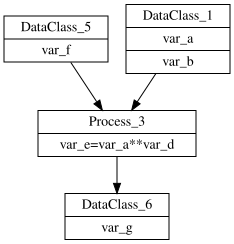

In [7]:
composite = CompositeProcess("Process_3", [Process_3])

g = ProcessGraph()
g.add_process(composite)
# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))


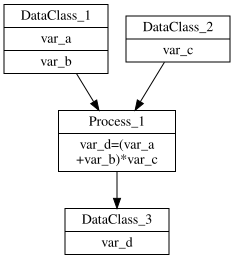

In [8]:
composite = CompositeProcess("Process_1", [Process_1])

g = ProcessGraph()
g.add_process(composite)
# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

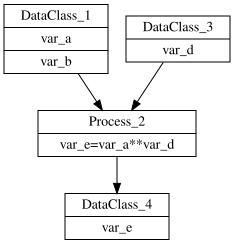

In [9]:
composite = CompositeProcess("Process_2", [Process_2])

g = ProcessGraph()
g.add_process(composite)
# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

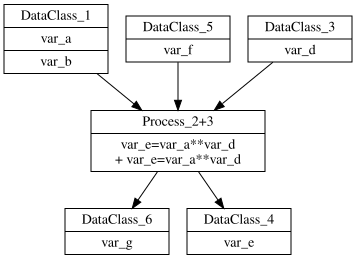

In [10]:
composite = CompositeProcess("Process_2+3", [Process_2, Process_3])

g = ProcessGraph()
g.add_process(composite)
# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

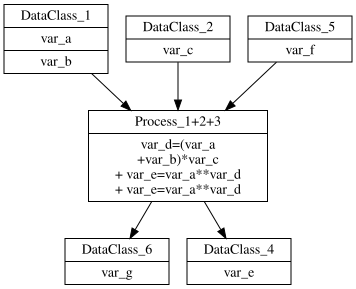

In [11]:
composite = CompositeProcess("Process_1+2+3", [Process_1, Process_2, Process_3])

g = ProcessGraph()
g.add_process(composite)
# Display the graph (assuming Jupyter environment)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

In [12]:
from dataclasses import dataclass, fields
from typing import Dict, Any, Type, List, Union
import graphviz
from IPython.display import display, SVG
from sdata.sclass.process import ProcessData, ProcessNode
# Assuming the full code for Base, ProcessData, SUUID, Metadata, etc. is defined as provided.

# ProcessData remains as before

class DataClass_1(ProcessData):
    default_attributes = [
        {"name": "var_a", "value": None, "dtype": "float", "description": "Variable A", "required": True},
        {"name": "var_b", "value": None, "dtype": "float", "description": "Variable B", "required": True},
    ]

class DataClass_2(ProcessData):
    default_attributes = [
        {"name": "var_c", "value": None, "dtype": "float", "description": "Variable C", "required": True},
    ]

class DataClass_3(ProcessData):
    default_attributes = [
        {"name": "var_d", "value": None, "dtype": "float", "description": "Variable D", "required": True},
    ]

class DataClass_4(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

# Now, Process inherits from ProcessNode
class Process(ProcessNode):
    input_classes: Dict[str, Type[ProcessData]] = {}
    output_classes: Dict[str, Type[ProcessData]] = {}
    computation: str = ""

    required_inputs: List[Type[ProcessData]] = []  # To be set in subclasses
    required_outputs: List[Type[ProcessData]] = []  # To be set in subclasses

    def __init__(self, name: str = "Process", inputs: Dict[str, ProcessData] = None, **kwargs: Any):
        super().__init__(name=name, inputs=inputs, **kwargs)
        # Set required_inputs/outputs from class vars if not overridden
        if not self.required_inputs:
            self.required_inputs = list(self.input_classes.values())
        if not self.required_outputs:
            self.required_outputs = list(self.output_classes.values())

    def execute(self) -> Dict[str, ProcessData]:
        if not self.validate_inputs():
            raise ValueError("Inputs not valid")
        raise NotImplementedError

class Process_1(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2}
    output_classes = {'DataClass_3': DataClass_3}
    computation = "var_d=(var_a+var_b)*var_c"

    required_inputs = [DataClass_1, DataClass_2]
    required_outputs = [DataClass_3]

    def execute(self) -> Dict[str, ProcessData]:
        super().execute()  # Calls validate_inputs indirectly via super's execute if needed, but here we override
        self.validate_inputs()
        dc1 = self.inputs['DataClass_1']
        dc2 = self.inputs['DataClass_2']
        var_a = dc1.metadata.get("var_a").value
        var_b = dc1.metadata.get("var_b").value
        var_c = dc2.metadata.get("var_c").value
        var_d = (var_a + var_b) * var_c
        dc3 = DataClass_3(name="dc3")
        dc3.metadata.add("var_d", var_d, dtype="float", description="Computed var_d", required=True)
        self.outputs = {'DataClass_3': dc3}
        return self.outputs

class Process_2(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3}
    output_classes = {'DataClass_4': DataClass_4}
    computation = "var_e=var_a**var_d"

    required_inputs = [DataClass_1, DataClass_3]
    required_outputs = [DataClass_4]

    def execute(self) -> Dict[str, ProcessData]:
        self.validate_inputs()
        dc1 = self.inputs['DataClass_1']
        dc3 = self.inputs['DataClass_3']
        var_a = dc1.metadata.get("var_a").value
        var_d = dc3.metadata.get("var_d").value
        var_e = var_a ** var_d
        dc4 = DataClass_4(name="dc4")
        dc4.metadata.add("var_e", var_e, dtype="float", description="Computed var_e", required=True)
        self.outputs = {'DataClass_4': dc4}
        return self.outputs

class CompositeProcess(ProcessNode):
    def __init__(self, name: str, processes: List[Type[Process]], inputs: Dict[str, ProcessData] = None, **kwargs: Any):
        super().__init__(name=name, inputs=inputs, **kwargs)
        self.process_classes = processes  # Store class types
        self.input_classes: Dict[str, Type[ProcessData]] = {}
        self.output_classes: Dict[str, Type[ProcessData]] = {}
        self.computation = ""
        self._compute_aggregated_io()
        self.required_inputs = list(self.input_classes.values())
        self.required_outputs = list(self.output_classes.values())

    def _compute_aggregated_io(self):
        all_inputs = set()
        all_outputs = set()
        internal_connections = set()

        for proc_type in self.process_classes:
            for inp in proc_type.input_classes.keys():
                all_inputs.add(inp)
            for out in proc_type.output_classes.keys():
                all_outputs.add(out)

        for i, proc_type in enumerate(self.process_classes):
            for out in proc_type.output_classes.keys():
                for next_proc_type in self.process_classes[i+1:]:
                    if out in next_proc_type.input_classes:
                        internal_connections.add(out)

        external_inputs = all_inputs - internal_connections
        external_outputs = all_outputs - all_inputs

        for inp in external_inputs:
            for proc_type in self.process_classes:
                if inp in proc_type.input_classes:
                    self.input_classes[inp] = proc_type.input_classes[inp]
                    break

        for out in external_outputs:
            for proc_type in self.process_classes:
                if out in proc_type.output_classes:
                    self.output_classes[out] = proc_type.output_classes[out]
                    break

        self.computation = " + ".join([p.computation for p in self.process_classes])

    def execute(self) -> Dict[str, ProcessData]:
        if not self.validate_inputs():
            raise ValueError("Inputs not valid")
        intermediate = self.inputs.copy()
        for proc_type in self.process_classes:
            proc = proc_type(inputs={k: intermediate[k] for k in proc_type.input_classes if k in intermediate})
            proc_output = proc.execute()
            intermediate.update(proc_output)
        self.outputs = {k: intermediate[k] for k in self.output_classes}
        return self.outputs

class ProcessGraph:
    def __init__(self):
        self.data_nodes = set()
        self.process_nodes = set()
        self.edges = []
        self.class_map: Dict[str, Type[ProcessData]] = {}
        self.process_class_map: Dict[str, Union[Type[Process], Type[CompositeProcess]]] = {}

    def add_process(self, process_class: Union[Type[Process], Type[CompositeProcess]]):
        proc_name = process_class.__name__ if hasattr(process_class, '__name__') else process_class.name
        self.process_nodes.add(proc_name)
        self.process_class_map[proc_name] = process_class
        
        if hasattr(process_class, 'input_classes'):
            input_classes = process_class.input_classes
            output_classes = process_class.output_classes
            computation = process_class.computation
        else:
            # For CompositeProcess, since it's not a type but class, but in usage we instantiate first? Wait, adjust.
            # To work with classes, we can make CompositeProcess a class factory or adjust.
            # Assuming we pass CompositeProcess instance for now, but to match "with class not instances", let's assume process_class is the class.
            # But CompositeProcess has init with processes, so perhaps create a subclass.
            raise Exception(f"add_process has a problem withn the process_class {process_class}")
        # To handle composites as classes, we can define them as subclasses.
        # For simplicity, assume add_process takes the class or composite instance, but use class properties.

        for input_name, input_class in input_classes.items():
            self.data_nodes.add(input_name)
            self.class_map[input_name] = input_class
            self.edges.append((input_name, proc_name))
        
        for output_name, output_class in output_classes.items():
            self.data_nodes.add(output_name)
            self.class_map[output_name] = output_class
            self.edges.append((proc_name, output_name))

    def to_graphviz(self, name="SumSquare", rankdir="TD", collapsed=True):
        dot = graphviz.Digraph(name=name, graph_attr={'rankdir': rankdir})
        
        for data in self.data_nodes:
            cls = self.class_map[data]
            fields = [attr['name'] for attr in cls.default_attributes if 'name' in attr]
            label = '{' + data + ' | ' + ' | '.join(fields) + '}'
            dot.node(data, shape='record', label=label)
        
        for proc in self.process_nodes:
            proc_class = self.process_class_map[proc]
            if hasattr(proc_class, 'computation'):
                computation = proc_class.computation
            label = '{' + proc + ' | ' + computation.replace('+', '\\n+') + '}'
            dot.node(proc, shape='record', label=label)
        
        for src, dst in self.edges:
            dot.edge(src, dst)
        
        return dot

# To make CompositeProcess work with classes, we can define it as a class
class Process_1_plus_2(CompositeProcess):
    def __init__(self, inputs: Dict[str, ProcessData] = None, **kwargs):
        super().__init__(name="Process_1+2", processes=[Process_1, Process_2], inputs=inputs, **kwargs)

# Now add the class
g = ProcessGraph()
g.add_process(Process_1_plus_2)  # Add the composite class

# Display
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

# Execution with instances
dc1 = DataClass_1(name="dc1")
dc1.metadata.add("var_a", 2.0, dtype="float", required=True)
dc1.metadata.add("var_b", 3.0, dtype="float", required=True)

dc2 = DataClass_2(name="dc2")
dc2.metadata.add("var_c", 4.0, dtype="float", required=True)

inputs = {
    'DataClass_1': dc1,
    'DataClass_2': dc2
}
composite = Process_1_plus_2(inputs=inputs)
output = composite.execute()
dc4 = output['DataClass_4']
print(dc4.metadata.get("var_e").value)  # Outputs: 1048576.0

Exception: add_process has a problem withn the process_class <class '__main__.Process_1_plus_2'>

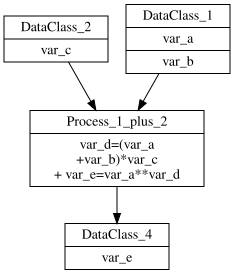

NotImplementedError: 

In [12]:
from dataclasses import dataclass, fields
from typing import Dict, Any, Type, List, Union
import graphviz
from IPython.display import display, SVG

# Assuming the full code for Base, ProcessData, SUUID, Metadata, ProcessNode, etc. is defined as provided.

# ProcessData remains as before

class DataClass_1(ProcessData):
    default_attributes = [
        {"name": "var_a", "value": None, "dtype": "float", "description": "Variable A", "required": True},
        {"name": "var_b", "value": None, "dtype": "float", "description": "Variable B", "required": True},
    ]

class DataClass_2(ProcessData):
    default_attributes = [
        {"name": "var_c", "value": None, "dtype": "float", "description": "Variable C", "required": True},
    ]

class DataClass_3(ProcessData):
    default_attributes = [
        {"name": "var_d", "value": None, "dtype": "float", "description": "Variable D", "required": True},
    ]

class DataClass_4(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

# Process inherits from ProcessNode
class Process(ProcessNode):
    input_classes: Dict[str, Type[ProcessData]] = {}
    output_classes: Dict[str, Type[ProcessData]] = {}
    computation: str = ""

    required_inputs: List[Type[ProcessData]] = []
    required_outputs: List[Type[ProcessData]] = []

    def __init__(self, name: str = "Process", inputs: Dict[str, ProcessData] = None, **kwargs: Any):
        super().__init__(name=name, inputs=inputs, **kwargs)
        if not self.required_inputs:
            self.required_inputs = list(self.input_classes.values())
        if not self.required_outputs:
            self.required_outputs = list(self.output_classes.values())

    def execute(self) -> Dict[str, ProcessData]:
        if not self.validate_inputs():
            raise ValueError("Inputs not valid")
        raise NotImplementedError

class Process_1(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2}
    output_classes = {'DataClass_3': DataClass_3}
    computation = "var_d=(var_a+var_b)*var_c"

    required_inputs = [DataClass_1, DataClass_2]
    required_outputs = [DataClass_3]

    def execute(self) -> Dict[str, ProcessData]:
        super().execute()  # Optional, since we call validate below
        self.validate_inputs()
        dc1 = self.inputs['DataClass_1']
        dc2 = self.inputs['DataClass_2']
        var_a = dc1.metadata.get("var_a").value
        var_b = dc1.metadata.get("var_b").value
        var_c = dc2.metadata.get("var_c").value
        var_d = (var_a + var_b) * var_c
        dc3 = DataClass_3(name="dc3")
        dc3.metadata.add("var_d", var_d, dtype="float", description="Computed var_d", required=True)
        self.outputs = {'DataClass_3': dc3}
        return self.outputs

class Process_2(Process):
    input_classes = {'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3}
    output_classes = {'DataClass_4': DataClass_4}
    computation = "var_e=var_a**var_d"

    required_inputs = [DataClass_1, DataClass_3]
    required_outputs = [DataClass_4]

    def execute(self) -> Dict[str, ProcessData]:
        self.validate_inputs()
        dc1 = self.inputs['DataClass_1']
        dc3 = self.inputs['DataClass_3']
        var_a = dc1.metadata.get("var_a").value
        var_d = dc3.metadata.get("var_d").value
        var_e = var_a ** var_d
        dc4 = DataClass_4(name="dc4")
        dc4.metadata.add("var_e", var_e, dtype="float", description="Computed var_e", required=True)
        self.outputs = {'DataClass_4': dc4}
        return self.outputs

class CompositeProcess(ProcessNode):
    def __init__(self, name: str, processes: List[Type[Process]], inputs: Dict[str, ProcessData] = None, **kwargs: Any):
        super().__init__(name=name, inputs=inputs, **kwargs)
        self.process_classes = processes  # Store class types
        self.input_classes: Dict[str, Type[ProcessData]] = {}
        self.output_classes: Dict[str, Type[ProcessData]] = {}
        self.computation = ""
        self._compute_aggregated_io()
        self.required_inputs = list(self.input_classes.values())
        self.required_outputs = list(self.output_classes.values())

    def _compute_aggregated_io(self):
        all_inputs = set()
        all_outputs = set()
        internal_connections = set()

        for proc_type in self.process_classes:
            for inp in proc_type.input_classes.keys():
                all_inputs.add(inp)
            for out in proc_type.output_classes.keys():
                all_outputs.add(out)

        for i, proc_type in enumerate(self.process_classes):
            for out in proc_type.output_classes.keys():
                for next_proc_type in self.process_classes[i+1:]:
                    if out in next_proc_type.input_classes:
                        internal_connections.add(out)

        external_inputs = all_inputs - internal_connections
        external_outputs = all_outputs - all_inputs

        for inp in external_inputs:
            for proc_type in self.process_classes:
                if inp in proc_type.input_classes:
                    self.input_classes[inp] = proc_type.input_classes[inp]
                    break

        for out in external_outputs:
            for proc_type in self.process_classes:
                if out in proc_type.output_classes:
                    self.output_classes[out] = proc_type.output_classes[out]
                    break

        self.computation = " + ".join([p.computation for p in self.process_classes])

    def execute(self) -> Dict[str, ProcessData]:
        if not self.validate_inputs():
            raise ValueError("Inputs not valid")
        intermediate = self.inputs.copy()
        for proc_type in self.process_classes:
            proc = proc_type(inputs={k: intermediate[k] for k in proc_type.input_classes if k in intermediate})
            proc_output = proc.execute()
            intermediate.update(proc_output)
        self.outputs = {k: intermediate[k] for k in self.output_classes}
        return self.outputs

class ProcessGraph:
    def __init__(self):
        self.data_nodes = set()
        self.process_nodes = set()
        self.edges = []
        self.class_map: Dict[str, Type[ProcessData]] = {}
        self.process_class_map: Dict[str, Union[Type[Process], Type[CompositeProcess]]] = {}

    def add_process(self, process_class: Union[Type[Process], Type[CompositeProcess]]):
        proc_name = process_class.__name__ if hasattr(process_class, '__name__') else process_class.name
        self.process_nodes.add(proc_name)
        self.process_class_map[proc_name] = process_class
        
        # Instantiate a dummy to get attributes, as composites set them in __init__
        dummy = process_class(inputs=None)  # Use inputs=None for dummy
        input_classes = dummy.input_classes
        output_classes = dummy.output_classes
        # computation = dummy.computation  # Not needed here, but for consistency
        
        for input_name, input_class in input_classes.items():
            self.data_nodes.add(input_name)
            self.class_map[input_name] = input_class
            self.edges.append((input_name, proc_name))
        
        for output_name, output_class in output_classes.items():
            self.data_nodes.add(output_name)
            self.class_map[output_name] = output_class
            self.edges.append((proc_name, output_name))

    def to_graphviz(self, name="SumSquare", rankdir="TD", collapsed=True):
        dot = graphviz.Digraph(name=name, graph_attr={'rankdir': rankdir})
        
        for data in self.data_nodes:
            cls = self.class_map[data]
            fields = [attr['name'] for attr in cls.default_attributes if 'name' in attr]
            label = '{' + data + ' | ' + ' | '.join(fields) + '}'
            dot.node(data, shape='record', label=label)
        
        for proc in self.process_nodes:
            proc_class = self.process_class_map[proc]
            # Instantiate dummy to get computation
            dummy = proc_class(inputs=None)
            computation = dummy.computation
            label = '{' + proc + ' | ' + computation.replace('+', '\\n+') + '}'
            dot.node(proc, shape='record', label=label)
        
        for src, dst in self.edges:
            dot.edge(src, dst)
        
        return dot

# Define composite as subclass
class Process_1_plus_2(CompositeProcess):
    def __init__(self, inputs: Dict[str, ProcessData] = None, **kwargs):
        super().__init__(name="Process_1+2", processes=[Process_1, Process_2], inputs=inputs, **kwargs)

# Usage
g = ProcessGraph()
g.add_process(Process_1_plus_2)

# Display
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

# Execution
dc1 = DataClass_1(name="dc1")
dc1.metadata.add("var_a", 2.0, dtype="float", required=True)
dc1.metadata.add("var_b", 3.0, dtype="float", required=True)

dc2 = DataClass_2(name="dc2")
dc2.metadata.add("var_c", 4.0, dtype="float", required=True)

inputs = {
    'DataClass_1': dc1,
    'DataClass_2': dc2
}
composite = Process_1_plus_2(inputs=inputs)
output = composite.execute()
dc4 = output['DataClass_4']
print(dc4.metadata.get("var_e").value)  # Outputs: 1048576.0

In [13]:
from typing import Dict, Type, List
# Assuming Process, ProcessData, ProcessNode, etc., are defined as before.

from sdata.sclass.process import ProcessData, ProcessNode

def create_process_class(
    process_name: str,
    input_classes: Dict[str, Type[ProcessData]],
    output_classes: Dict[str, Type[ProcessData]],
) -> Type[ProcessNode]:
    """
    Factory function to generically create a subclass of Process.
    
    :param process_name: Name of the new process class (e.g., 'Process_1').
    :param input_classes: Dict mapping input names to ProcessData subclasses.
    :param output_classes: Dict mapping output names to ProcessData subclasses.
    :param computation: String representing the computation (e.g., 'var_d=(var_a+var_b)*var_c').
    :return: A new subclass of Process.
    """
    if len(output_classes) != 1:
        raise ValueError("Currently supports only single output class.")
    
    output_key = list(output_classes.keys())[0]
    output_class = output_classes[output_key]
    
    class_dict = {
        'input_classes': input_classes,
        'output_classes': output_classes,
        'required_inputs': list(input_classes.values()),
        'required_outputs': list(output_classes.values()),
    }
    
    return type(process_name, (ProcessNode,), class_dict)

# Example usage to recreate Process_1 generically
Process_1_Generic = create_process_class(
    'Process_1',
    input_classes={'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2},
    output_classes={'DataClass_3': DataClass_3},
)
Process_1_Generic
# Now Process_1_Generic is equivalent to the original Process_1 class
# You can instantiate it: p1 = Process_1_Generic(inputs=...)

__main__.Process_1

In [14]:
Process_1_Generic

__main__.Process_1

In [1]:
from sdata.sclass.process import create_process_class, ProcessData, ProcessNode, CompositeProcess


class DataClass_1(ProcessData):
    default_attributes = [
        {"name": "var_a", "value": None, "dtype": "float", "description": "Variable A", "required": True},
        {"name": "var_b", "value": None, "dtype": "float", "description": "Variable B", "required": True},
    ]

class DataClass_2(ProcessData):
    default_attributes = [
        {"name": "var_c", "value": None, "dtype": "float", "description": "Variable C", "required": True},
    ]

class DataClass_3(ProcessData):
    default_attributes = [
        {"name": "var_d", "value": None, "dtype": "float", "description": "Variable D", "required": True},
    ]

class DataClass_4(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

class DataClass_5(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]

class DataClass_6(ProcessData):
    default_attributes = [
        {"name": "var_e", "value": None, "dtype": "float", "description": "Variable E", "required": True},
    ]



In [2]:
Process_1_Generic = create_process_class(
    'Process_1',
    input_classes={'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2},
    output_classes={'DataClass_3': DataClass_3, 'DataClass_6': DataClass_6},
)
Process_1_Generic

sdata.sclass.process.Process_1

In [3]:
Process_2_Generic = create_process_class(
    'Process_2',
    input_classes={'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3, 'DataClass_5': DataClass_5},
    output_classes={'DataClass_4': DataClass_4},
)
Process_2_Generic

sdata.sclass.process.Process_2

In [4]:
from typing import Dict, Type, List, Union
class Process_1_plus_2(CompositeProcess):
    def __init__(self, inputs: Dict[str, ProcessData] = None, **kwargs):
        super().__init__(name="Process_1+2", processes=[Process_1_Generic, Process_2_Generic], inputs=inputs, **kwargs)
composite = Process_1_plus_2(inputs={})
composite

<Process_1_plus_2@process_1_2@6efa9001977b4a41a99aa5ed17a6b8a7>

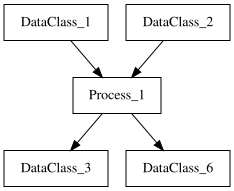

In [5]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(Process_1_Generic)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

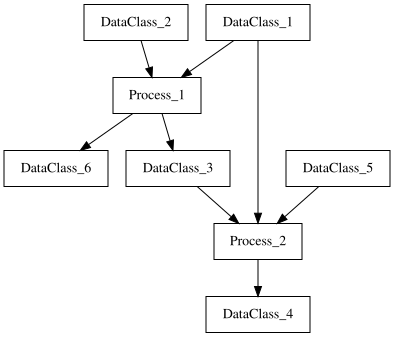

In [6]:
g = ProcessGraph()
g.add_process(Process_1_Generic)
g.add_process(Process_2_Generic)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

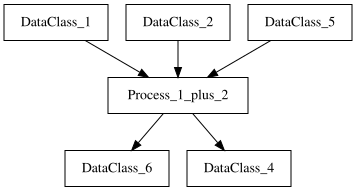

In [7]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(Process_1_plus_2)
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))